In [1]:
import glob
import os
from astropy.io import fits

# Sort the FITS file list deterministically so every downstream loop
# (raw .txt dump for SUPPNet in cell 5, zarr ingestion in cell 9) sees the
# same ordering on re-runs and on different filesystems.  Without sorting,
# glob.glob() returns directory-order, which is not portable and causes the
# normalized rows produced by SUPPNet to silently desync from the
# wavelengths/bjds rows written here.
fits_files = sorted(glob.glob('data/*.fits'))
# Keep a dedicated handle for the exploratory cells below.  Cell 5 uses its
# own ``with fits.open(...)`` and must not reuse the name ``hdul`` here.
SAMPLE_IDX = 0
hdul_sample = fits.open(fits_files[SAMPLE_IDX])

In [2]:
hdul_sample[1].data

FITS_rec([([3781.24, 3781.25, 3781.26, ..., 6912.78, 6912.79, 6912.8 ], [  702.6959 ,   587.0522 ,   482.9682 , ...,  5273.434  ,  4491.642  ,  3704.0295 ], [nan, nan, nan, ..., nan, nan, nan])],
         dtype=(numpy.record, [('WAVE', '>f8', (313157,)), ('FLUX', '>f4', (313157,)), ('ERR', '>f4', (313157,))]))

In [3]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [4]:
len(hdul_sample[1].data['FLUX'][0])

313157

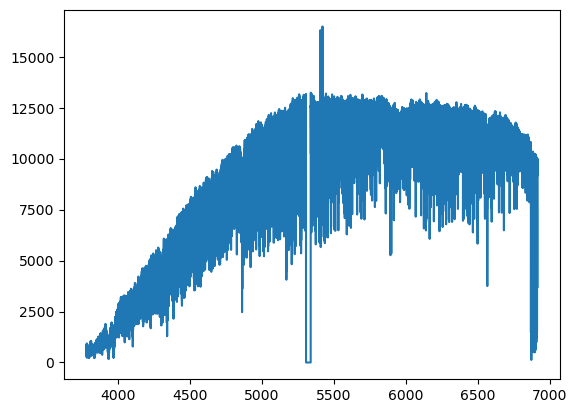

In [5]:
plt.plot(hdul_sample[1].data['WAVE'][0], hdul_sample[1].data['FLUX'][0])

In [6]:
import numpy as np

# spectrum<i>.txt indexing must follow the same `fits_files` order as cell 9
# (which writes the zarr arrays).  Both cells consume the sorted-glob list set
# in cell 0, so SUPPNet's spectrum<i>.all output maps row-for-row to
# wavelengths[i] / fluxes[i] / bjds[i] / source_files[i] in the zarr.
os.makedirs('raw_data', exist_ok=True)
with open('raw_data/spectrum_index.txt', 'w') as idx:
    for i, fits_file in enumerate(fits_files):
        try:
            with fits.open(fits_file) as hdul_file:
                data_to_save = np.column_stack((
                    hdul_file[1].data['WAVE'][0],
                    hdul_file[1].data['FLUX'][0],
                    hdul_file[1].data['ERR'][0],
                ))
            np.savetxt(f"raw_data/spectrum{i}.txt", data_to_save, delimiter=" ", comments='')
            idx.write(f'{i}\t{os.path.basename(fits_file)}\n')
        except Exception as e:
            print(f'skipped {os.path.basename(fits_file)}: {e!r}')
            continue
print(f'wrote {len(fits_files)} spectrum<i>.txt files and raw_data/spectrum_index.txt')

skipped ADP.2014-10-07T08:34:07.833.fits: OSError('Empty or corrupt FITS file')
wrote 22 spectrum<i>.txt files and raw_data/spectrum_index.txt


In [7]:
hdul_sample[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
DATASUM = '0       '           / data unit checksum updated 2014-09-16T13:24:30 
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H   
DATE    = '2010-09-15T01:42:07.943' / Date this file was written                
INSTRUME= 'HARPS   '           / Instrument used                                
RA      =            48.672240 / 03:14:41.3 RA (J2000) pointing                 
DEC     =            -35.55970 / -35:33:34.9 DEC (J2000) pointing               
EQUINOX =                2000. / Standard FK5 (years)                           
RADECSYS= 'FK5     '        

In [8]:
hdul_sample[0].header['HIERARCH ESO DRS BJD']

2454887.5473123

In [9]:
import numpy as np
len(hdul_sample[1].data['WAVE'][0][np.isclose(hdul_sample[1].data['FLUX'][0], 0)])

3295

In [10]:
from tqdm import tqdm
wavelengths = []
fluxes = []
errors = []
source_files = []

snrs = []
mjd_starts = []
mjd_ends = []
exptimes = []
bjds = []
bervs = []
airmasses = []
objects = []
ccf_rvs = []
skipped = []

# HARPS DRS s1d/ADP products: WAVE is already in the barycentric frame
# (SPECSYS=BARYCENT), wavelengths are in air, BJD is barycentric, no stellar
# RV is applied.  We store BERV/AIRMASS/OBJECT/CCF-RV alongside the spectra
# so that frame, telluric, and target sanity checks can be done later
# without re-opening the FITS files.
for f in tqdm(fits_files):
    try:
        with fits.open(f) as hdul_file:
            wvs = hdul_file[1].data['WAVE'][0]
            flx = hdul_file[1].data['FLUX'][0]
            err = hdul_file[1].data['ERR'][0]
            h = hdul_file[0].header
            snr = h['SNR']
            mjd_start = h['MJD-OBS']
            mjd_end = h['MJD-END']
            exptime = h['EXPTIME']
            bjd = h['HIERARCH ESO DRS BJD']
            berv = h.get('HIERARCH ESO DRS BERV', float('nan'))
            airmass = h.get('AIRMASS', float('nan'))
            obj = h.get('OBJECT', '')
            ccf_rv = h.get('HIERARCH ESO DRS CCF RV', float('nan'))
    except Exception as e:
        print(f'skipped {os.path.basename(f)}: {e!r}')
        skipped.append(os.path.basename(f))
        continue
    wavelengths.append(wvs)
    fluxes.append(flx)
    errors.append(err)
    source_files.append(os.path.basename(f))
    snrs.append(snr)
    mjd_starts.append(mjd_start)
    mjd_ends.append(mjd_end)
    exptimes.append(exptime)
    bjds.append(bjd)
    bervs.append(berv)
    airmasses.append(airmass)
    objects.append(obj)
    ccf_rvs.append(ccf_rv)

print(f'kept {len(source_files)} / {len(fits_files)} files (skipped {len(skipped)})')
# Sanity: every spectrum should be of TZ For; complain about contaminants now,
# not silently after ingestion.
unique_objects = sorted(set(objects))
if len(unique_objects) > 1:
    print(f'WARNING: mixed OBJECT keywords across exposures: {unique_objects}')

100%|██████████| 22/22 [00:00<00:00, 83.14it/s]

skipped ADP.2014-10-07T08:34:07.833.fits: OSError('Empty or corrupt FITS file')
kept 21 / 22 files (skipped 1)


In [11]:
# Find the maximum length
maxlen = max([len(wvs) for wvs in wavelengths])

# Pad all arrays to the same size
wavelengths_padded = np.array([np.pad(wvs, (0, maxlen - len(wvs)), constant_values=np.nan) for wvs in wavelengths])
fluxes_padded = np.array([np.pad(flx, (0, maxlen - len(flx)), constant_values=np.nan) for flx in fluxes])
errors_padded = np.array([np.pad(err, (0, maxlen - len(err)), constant_values=np.nan) for err in errors])

In [12]:
import zarr
import numpy as np
from zarr.codecs import BloscCodec

root = zarr.open_group(
    "harps_data.zarr",
    mode="w",
    zarr_version=3
)

compressor = BloscCodec(cname="zstd", clevel=3)

root.create_array(
    "wavelengths",
    data=wavelengths_padded,
    fill_value=np.nan,
    compressors=[compressor]
)

root.create_array(
    "fluxes",
    data=fluxes_padded,
    fill_value=np.nan,
    compressors=[compressor]
)

root.create_array(
    "errors",
    data=errors_padded,
    fill_value=np.nan,
    compressors=[compressor]
)

root.create_array("snrs", data=np.asarray(snrs))
root.create_array("mjd_starts", data=np.asarray(mjd_starts))
root.create_array("mjd_ends", data=np.asarray(mjd_ends))
root.create_array("exptimes", data=np.asarray(exptimes))
root.create_array("bjds", data=np.asarray(bjds))
root.create_array("bervs", data=np.asarray(bervs))
root.create_array("airmasses", data=np.asarray(airmasses))
root.create_array("ccf_rvs", data=np.asarray(ccf_rvs))

# Provenance attributes.  `raw_source_files` is the canonical row->FITS
# mapping; downstream notebooks must use it to re-key any data that comes
# from a different ordering (e.g. SUPPNet outputs sorted by spectrum<N>.all).
root.attrs['raw_source_files'] = source_files
root.attrs['objects'] = objects
root.attrs['wave_frame'] = 'BARYCENT'          # SPECSYS in headers
root.attrs['wave_units'] = 'Angstrom'
root.attrs['wave_air_or_vacuum'] = 'air'       # HARPS pipeline default
root.attrs['bjd_scale'] = 'BJD_UTC'            # HARPS DRS convention
root.attrs['notes'] = (
    'BERV already applied by HARPS DRS (SPECSYS=BARYCENT). No stellar RV '
    'or systemic-velocity correction has been applied; spectra still '
    'contain gamma + binary orbital RVs. No telluric correction.'
)

print(f'Saved {len(source_files)} spectra to harps_data.zarr (Zarr v3)')

Saved 21 spectra to harps_data.zarr (Zarr v3)


In [13]:
# Validate that:
#   * every raw wavelength row was written instead of falling back to the fill value,
#   * all metadata columns have the same length as the spectra array, and
#   * `raw_source_files` is sorted by filename, so downstream code that joins
#     on row index sees a stable ordering across re-runs and machines.
#     (Note: ADP filenames are ESO archive ingestion timestamps, NOT
#     observation times -- BJDs will *not* be monotonic in row order, and
#     that is fine.  Phasing is done from `bjds`, not from row index.)
written = zarr.open_group('harps_data.zarr', mode='r')
nrows = written['wavelengths'].shape[0]

bad_rows = []
for i in range(nrows):
    wave = written['wavelengths'][i, :]
    if not np.isfinite(wave).any():
        bad_rows.append(i)
if bad_rows:
    raise RuntimeError(f'Wavelength rows missing from Zarr write: {bad_rows}')

for key in ['fluxes', 'errors', 'snrs', 'mjd_starts', 'mjd_ends',
            'exptimes', 'bjds', 'bervs', 'airmasses', 'ccf_rvs']:
    n = written[key].shape[0]
    if n != nrows:
        raise RuntimeError(f'{key} has {n} rows but wavelengths has {nrows}')

saved_files = written.attrs['raw_source_files']
if len(saved_files) != nrows:
    raise RuntimeError(
        f'raw_source_files attr has {len(saved_files)} entries but '
        f'wavelengths has {nrows} rows'
    )
if saved_files != sorted(saved_files):
    raise RuntimeError(
        'raw_source_files is not sorted -- downstream row-index joins are '
        'not portable. Re-run cell 0 with sorted(glob.glob(...)).'
    )

print(f'Validated {nrows} rows; raw_source_files is sorted.')

Validated 21 rows; raw_source_files is sorted.
